In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

In [ ]:
fear_greed_df  = pd.read_csv("fear_greed_index.csv")
trader_df =pd.read_csv("historical_data.csv")

In [ ]:
def get_df_info(df):

    print("\n\033[1mShape of DataFrame:\033[0m ", df.shape)
    print("\n\033[1mColumns in DataFrame:\033[0m ", df.columns.to_list())
    print("\n\033[1mInformation about DataFrame:\033[0m")
    df.info()
    print("\n\033[1mUnique values per column:\033[0m")
    print(df.nunique())
    print("\n\033[1mNull values:\033[0m\n", df.isnull().sum())
    print("\n\033[1mDuplicate rows:\033[0m ", df.duplicated().sum())
    print("\n\033[1mDescriptive statistics:\033[0m\n", df.describe().transpose())

In [ ]:
get_df_info(fear_greed_df)


Shape of DataFrame:  (2644, 4)

Columns in DataFrame:  ['timestamp', 'value', 'classification', 'date']

Information about DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

Unique values per column:
timestamp         2644
value               90
classification       5
date              2644
dtype: int64

Null values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows:  0

Descriptive statistics:
             count          mean           std           min           25%  \
timestamp  2644.0  1.631899e+09  6.597967e+07  1.517463e+09  1.574811e+09   
valu

In [ ]:
get_df_info(trader_df)


Shape of DataFrame:  (211224, 16)

Columns in DataFrame:  ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Information about DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transact

In [ ]:
# Fear greed Data
fear_greed_df.columns = fear_greed_df.columns.str.strip().str.lower()
fear_greed_df["date"] = pd.to_datetime(fear_greed_df["date"])
fear_greed_df["classification"] = fear_greed_df["classification"].str.strip()
fear_greed_df = fear_greed_df.dropna(subset=["date","classification"])

In [ ]:
fear_greed_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
#Trader Data
trader_df.columns = (trader_df.columns.str.strip()
                        .str.lower()
                        .str.replace(" ","_")
                        .str.replace(r"[^a-z0-9_]","",regex=True))

In [ ]:
trader_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
# Cleaning and Merging Data

# 1. Standardize the Dates

trader_df['date'] = pd.to_datetime(trader_df['timestamp'], unit='ms', errors='coerce').dt.normalize()
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date'], errors='coerce').dt.normalize()

trader_df['closed_pnl'] = pd.to_numeric(trader_df['closed_pnl'], errors='coerce').fillna(0)

trader_df['is_long'] = trader_df['side'].astype(str).str.upper().isin(['BUY', 'LONG', 'B'])
trader_df['is_win'] = trader_df['closed_pnl'] > 0
trader_df['abs_pnl'] = trader_df['closed_pnl'].abs()

merged_df = pd.merge(trader_df, fear_greed_df, on='date', how='inner')

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged_df['classification'] = pd.Categorical(
    merged_df['classification'],
    categories=sentiment_order,
    ordered=True
)

In [ ]:
merged_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,fee,trade_id,timestamp_x,date,is_long,is_win,abs_pnl,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,0.345404,8.950000e+14,1.730000e+12,2024-10-27,True,False,0.0,1730007000,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,0.005600,4.430000e+14,1.730000e+12,2024-10-27,True,False,0.0,1730007000,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,1.730000e+12,2024-10-27,True,False,0.0,1730007000,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,0.050043,1.080000e+15,1.730000e+12,2024-10-27,True,False,0.0,1730007000,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,0.003055,1.050000e+15,1.730000e+12,2024-10-27,True,False,0.0,1730007000,74,Greed


In [ ]:
print(f"Total trades after merge: {len(merged_df):,}")
print(f"Total unique days matched: {merged_df['date'].nunique()}")
print("\nSentiment Breakdown:")
print(merged_df['classification'].value_counts().sort_index().to_string())

Total trades after merge: 184,263
Total unique days matched: 6

Sentiment Breakdown:
classification
Extreme Fear          0
Fear             133871
Neutral            7141
Greed             36289
Extreme Greed      6962


- During this 6-day window, the market was predominantly bleeding or scared.
- Nearly 3 out of every 4 trades happened while the Fear & Greed index was in "Fear".

--- Analyzing Sentiment Distribution ---


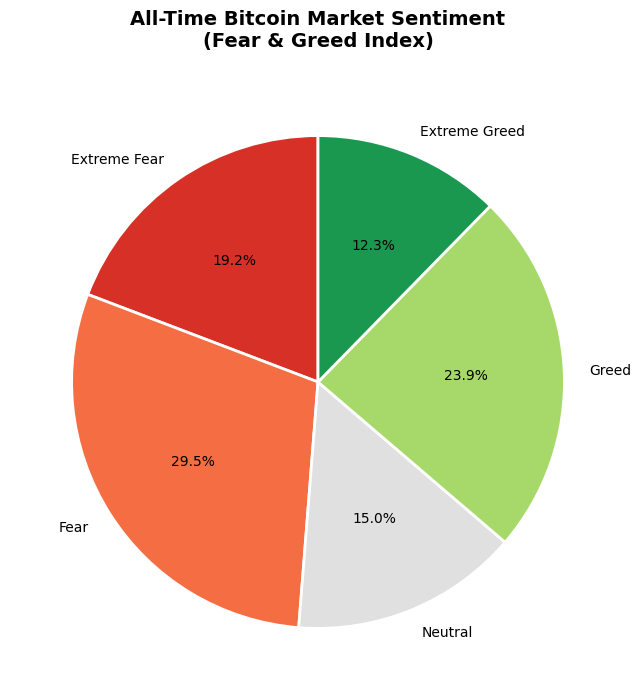

In [ ]:


print("--- Analyzing Sentiment Distribution ---")

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_colors = ['#d73027', '#f46d43', '#e0e0e0', '#a6d96a', '#1a9850']


vc = fear_greed_df['classification'].value_counts().reindex(sentiment_order).dropna()

# 3. Create the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(
    vc,
    labels=vc.index,
    colors=sentiment_colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title("All-Time Bitcoin Market Sentiment\n(Fear & Greed Index)", fontsize=14, fontweight='bold', pad=20)
plt.show()

--- Plotting Sentiment Timeline & Trade Distribution ---


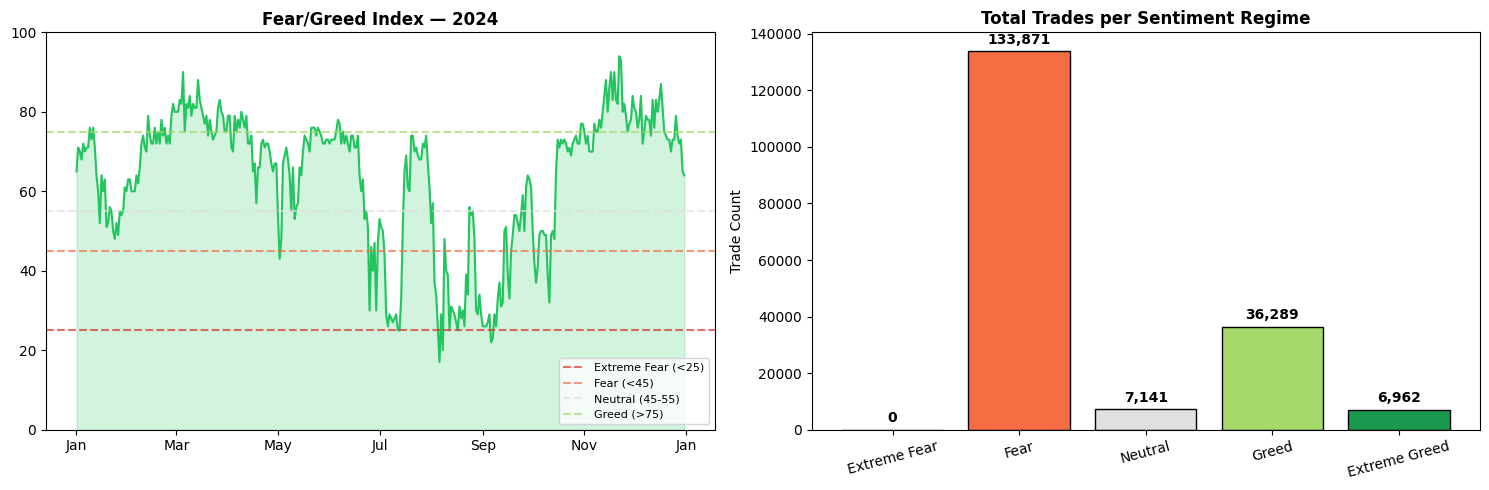

In [ ]:
import matplotlib.dates as mdates

print("--- Plotting Sentiment Timeline & Trade Distribution ---")

# 1. Setup the figure with 2 side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_colors = ['#d73027', '#f46d43', '#e0e0e0', '#a6d96a', '#1a9850']

# B: Sentiment Timeline (2024)

fg24 = fear_greed_df[(fear_greed_df['date'] >= '2024-01-01') & (fear_greed_df['date'] <= '2024-12-31')]
ax1.plot(fg24['date'], fg24['value'], color='#22C55E', linewidth=1.5)
ax1.fill_between(fg24['date'], fg24['value'], color='#22C55E', alpha=0.2)

ax1.axhline(25, color='#d73027', linestyle='--', alpha=0.7, label='Extreme Fear (<25)')
ax1.axhline(45, color='#f46d43', linestyle='--', alpha=0.7, label='Fear (<45)')
ax1.axhline(55, color='#e0e0e0', linestyle='--', alpha=0.7, label='Neutral (45-55)')
ax1.axhline(75, color='#a6d96a', linestyle='--', alpha=0.7, label='Greed (>75)')

ax1.set_title("Fear/Greed Index — 2024", fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.legend(loc="lower right", fontsize=8) # Moved lower right so it doesn't block data
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b")) # Shows 'Jan', 'Feb', etc.

# C: Trade Count per Sentiment Bar Chart

tc = merged_df['classification'].value_counts().reindex(sentiment_order).dropna()

bars = ax2.bar(tc.index, tc.values, color=sentiment_colors, edgecolor='black', linewidth=1)

# Add the text numbers perfectly on top of each bar
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (tc.max() * 0.02), # Add a tiny vertical offset so text floats
        f"{int(bar.get_height()):,}",         # Format with commas (e.g., 1,500)
        ha="center", fontsize=10, fontweight='bold'
    )

ax2.set_title("Total Trades per Sentiment Regime", fontsize=12, fontweight='bold')
ax2.set_ylabel("Trade Count")
ax2.tick_params(axis="x", rotation=15) # Tilt the labels slightly to prevent overlapping


plt.tight_layout()
plt.show()

--- Trader PnL Overview ---
Total closed PnL : $10,225,249.60
Mean PnL/trade   : $55.4927
Win rate         : 42.04%
Total trades     : 184,263
Unique accounts  : 32


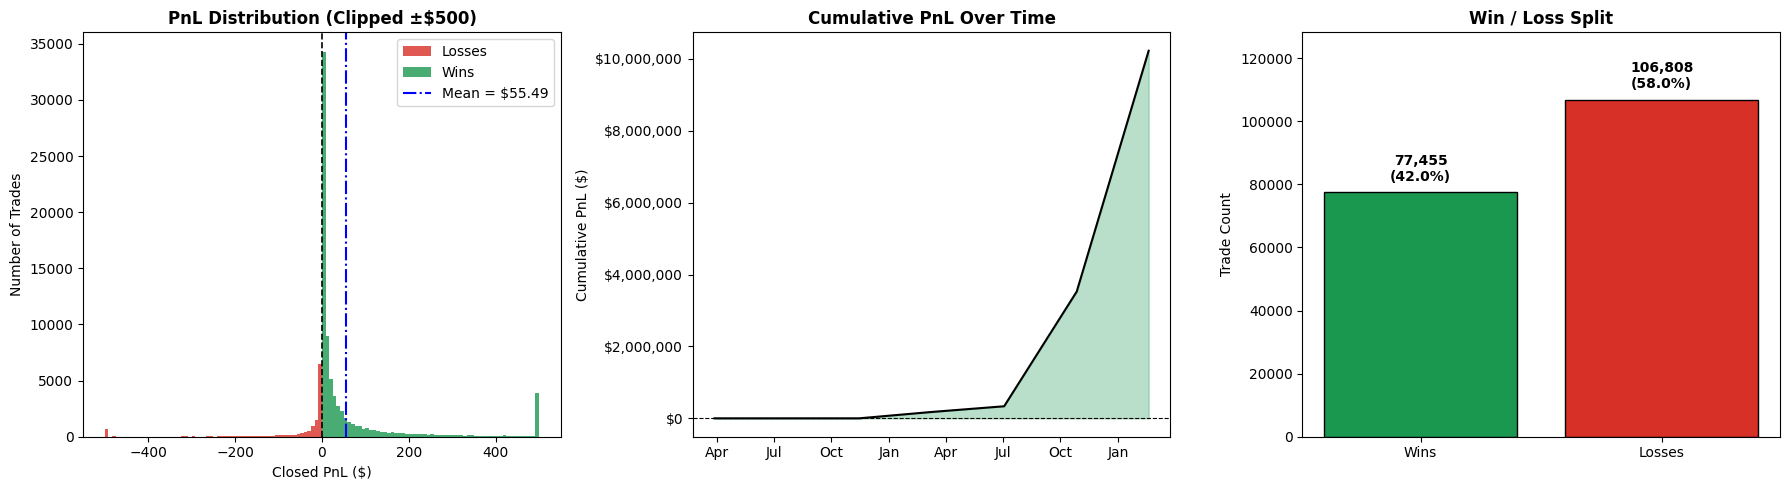

In [ ]:

print("--- Trader PnL Overview ---")

# 1. Calculate Core Statistics
total_pnl = merged_df["closed_pnl"].sum()
mean_pnl  = merged_df["closed_pnl"].mean()
win_rate  = merged_df["is_win"].mean() * 100
n_trades  = len(merged_df)

print(f"Total closed PnL : ${total_pnl:,.2f}")
print(f"Mean PnL/trade   : ${mean_pnl:,.4f}")
print(f"Win rate         : {win_rate:.2f}%")
print(f"Total trades     : {n_trades:,}")
print(f"Unique accounts  : {merged_df['account'].nunique():,}")
if "symbol" in merged_df.columns:
    print(f"Symbols traded   : {merged_df['symbol'].nunique():,}")

# 2. Setup the figure for 3 side-by-side charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Plot A: PnL Distribution (Histogram)
pnl_clipped = merged_df["closed_pnl"].clip(-500, 500) # Prevents massive outliers from ruining the chart

axes[0].hist(pnl_clipped[merged_df["closed_pnl"] < 0], bins=60, color='#d73027', alpha=0.8, label="Losses")
axes[0].hist(pnl_clipped[merged_df["closed_pnl"] > 0], bins=60, color='#1a9850', alpha=0.8, label="Wins")

axes[0].axvline(0, color="black", lw=1.2, ls="--")
axes[0].axvline(mean_pnl, color="blue", lw=1.5, ls="-.", label=f"Mean = ${mean_pnl:.2f}")

axes[0].set_title("PnL Distribution (Clipped ±$500)", fontweight='bold')
axes[0].set_xlabel("Closed PnL ($)")
axes[0].set_ylabel("Number of Trades")
axes[0].legend()

#  Plot B: Cumulative PnL Over Time (Line Chart)
# Group by Date and calculate the running total
daily_pnl = merged_df.groupby("date")["closed_pnl"].sum().sort_index()
cum_pnl   = daily_pnl.cumsum()

axes[1].plot(cum_pnl.index, cum_pnl.values, color="black", lw=1.5)

# Fill green if the portfolio is in profit, red if in drawdown
axes[1].fill_between(cum_pnl.index, cum_pnl.values, where=(cum_pnl.values >= 0), color="#1a9850", alpha=0.3)
axes[1].fill_between(cum_pnl.index, cum_pnl.values, where=(cum_pnl.values < 0), color="#d73027", alpha=0.3)

axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_title("Cumulative PnL Over Time", fontweight='bold')
axes[1].set_ylabel("Cumulative PnL ($)")

# Format the Y-axis to show dollars and X-axis to show Months
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))



#  Plot C: Win / Loss Ratio (Bar Chart)
wins = int(merged_df["is_win"].sum())
losses = n_trades - wins

bars = axes[2].bar(['Wins', 'Losses'], [wins, losses], color=['#1a9850', '#d73027'], edgecolor='black')

for i, val in enumerate([wins, losses]):
    axes[2].text(
        i, val + (n_trades * 0.02),
        f"{val:,}\n({(val/n_trades)*100:.1f}%)",
        ha="center", fontweight='bold', fontsize=10
    )

axes[2].set_title("Win / Loss Split", fontweight='bold')
axes[2].set_ylabel("Trade Count")
axes[2].set_ylim(0, max(wins, losses) * 1.2)

plt.tight_layout()
plt.show()

--- PnL by Sentiment Regime ---

Statistical Summary by Sentiment:
                Avg PnL  Median PnL   Total PnL  Std Dev  Trades
classification                                                  
Fear              50.05         0.0  6699925.19   909.12  133871
Neutral           22.23         0.0   158742.38   633.70    7141
Greed             87.89         0.0  3189616.54  1148.34   36289
Extreme Greed     25.42         0.0   176965.49   306.17    6962


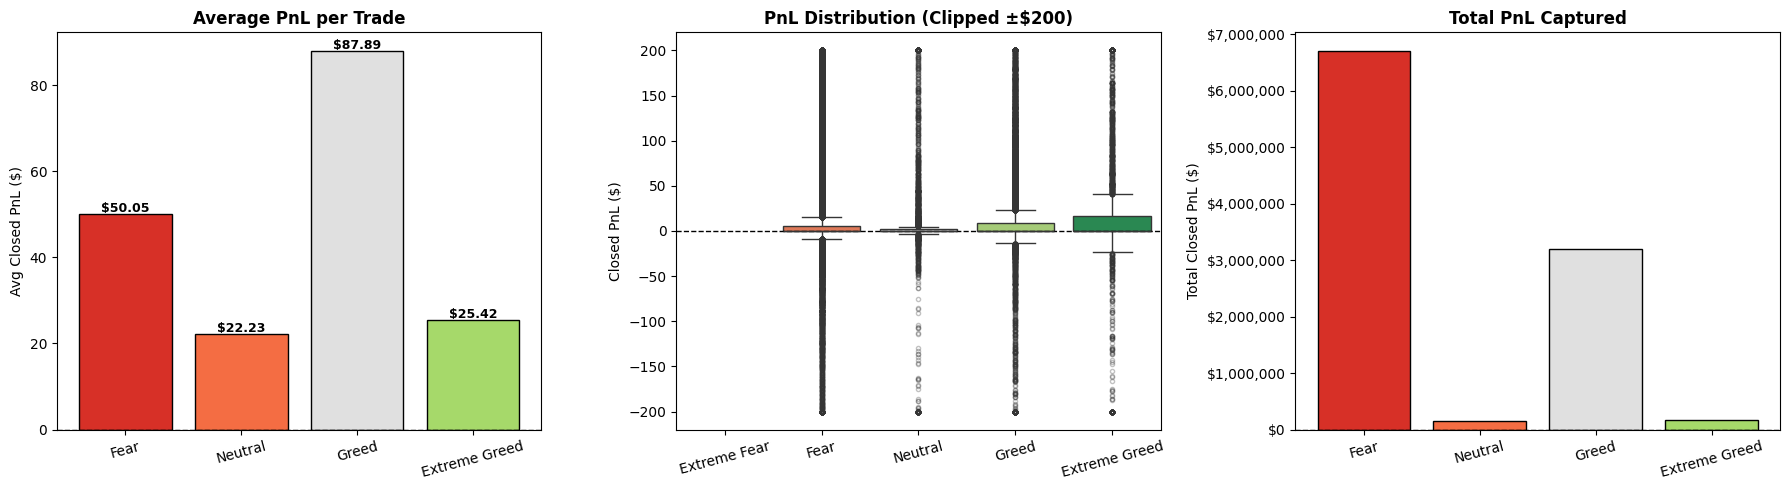

In [ ]:

print("--- PnL by Sentiment Regime ---")

# 1. Calculate Aggregated Statistics
sent_pnl = merged_df.groupby("classification", observed=True)["closed_pnl"].agg(
    ["mean", "median", "sum", "std", "count"]
).rename(columns={
    "mean": "Avg PnL", "median": "Median PnL",
    "sum": "Total PnL", "std": "Std Dev", "count": "Trades"
})

print("\nStatistical Summary by Sentiment:")
print(sent_pnl.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_colors = ['#d73027', '#f46d43', '#e0e0e0', '#a6d96a', '#1a9850']

# Plot A: Average PnL per Trade (Bar Chart)
bars1 = axes[0].bar(sent_pnl.index, sent_pnl["Avg PnL"], color=sentiment_colors, edgecolor="black")
axes[0].axhline(0, color="black", lw=1, ls="--")

for b in bars1:
    v = b.get_height()
    offset = 0.5 if v >= 0 else -2.5
    axes[0].text(b.get_x() + b.get_width()/2, v + offset, f"${v:.2f}", ha="center", fontsize=9, fontweight='bold')

axes[0].set_title("Average PnL per Trade", fontweight='bold')
axes[0].set_ylabel("Avg Closed PnL ($)")
axes[0].tick_params(axis="x", rotation=15)

#  Plot B: PnL Distribution Boxplot
merged_df['closedPnL_clipped'] = merged_df['closed_pnl'].clip(-200, 200)

sns.boxplot(
    data=merged_df,
    x='classification',
    y='closedPnL_clipped',
    ax=axes[1],
    palette=sentiment_colors,
    order=sentiment_order,
    showfliers=True,
    flierprops={"marker":"o", "ms":3, "alpha":0.3} # Format outlier dots
)

axes[1].axhline(0, color="black", lw=1, ls="--")
axes[1].set_title("PnL Distribution (Clipped ±$200)", fontweight='bold')
axes[1].set_ylabel("Closed PnL ($)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)



# Plot C: Total PnL Captured (Bar Chart)
bars3 = axes[2].bar(sent_pnl.index, sent_pnl["Total PnL"], color=sentiment_colors, edgecolor="black")
axes[2].axhline(0, color="black", lw=1, ls="--")

axes[2].set_title("Total PnL Captured", fontweight='bold')
axes[2].set_ylabel("Total Closed PnL ($)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Clean up the temporary column so it doesn't mess up future analysis
merged_df.drop(columns=['closedPnL_clipped'], inplace=True)


--- Win Rate & Trade Quality by Sentiment ---

Trade Quality Summary:
                Win Rate %   Wins  Total  Avg Win  Avg Loss  Profit Factor
classification                                                            
Fear                 48.82  10548  21607   354.28    -30.42          11.65
Neutral              42.97    672   1564   346.83   -127.24           2.73
Greed                35.54   1876   5278   227.29   -104.58           2.17
Extreme Greed        56.59   3124   5520    75.23    -25.59           2.94


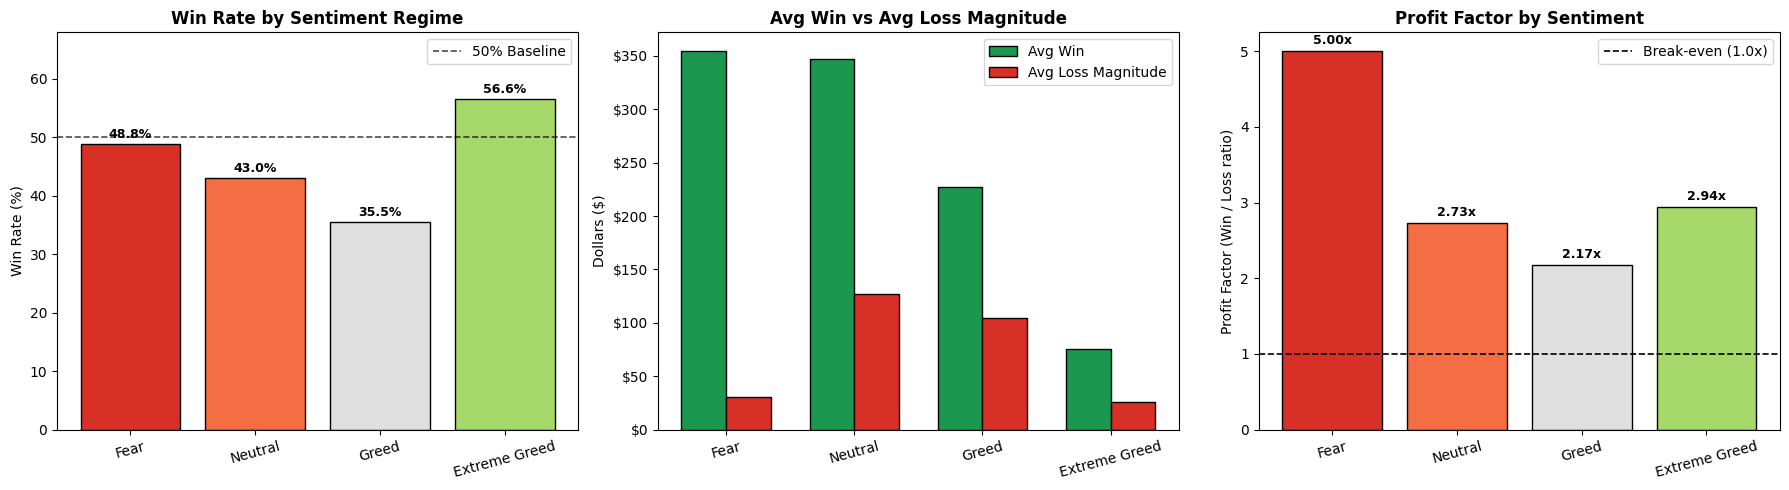

In [ ]:

# use our standard colors and order
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_colors = ['#d73027', '#f46d43', '#e0e0e0', '#a6d96a', '#1a9850']

print("\n" + "="*50)
print("--- Win Rate & Trade Quality by Sentiment ---")
print("="*50)

# 1. Calculate Aggregations
wr = merged_df.groupby("classification", observed=True).agg(
    Total=('is_win', 'count'),
    Wins=('is_win', 'sum'),
    Win_Rate=('is_win', 'mean')
)

wr["Win Rate %"] = wr["Win_Rate"] * 100
wr["Avg Win"] = merged_df[merged_df["is_win"]].groupby("classification", observed=True)["closed_pnl"].mean()
wr["Avg Loss"] = merged_df[~merged_df["is_win"]].groupby("classification", observed=True)["closed_pnl"].mean()
wr["Profit Factor"] = wr["Avg Win"] / wr["Avg Loss"].abs()

print("\nTrade Quality Summary:")
print(wr[["Win Rate %", "Wins", "Total", "Avg Win", "Avg Loss", "Profit Factor"]].round(2).to_string())

# 2. Plotting Section 6
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot A: Win Rate Bar Chart ──
bars_wr = axes[0].bar(wr.index, wr["Win Rate %"], color=sentiment_colors, edgecolor="black")
axes[0].axhline(50, color="black", lw=1.2, ls="--", alpha=0.7, label="50% Baseline")

for b in bars_wr:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 f"{b.get_height():.1f}%", ha="center", fontsize=9, fontweight='bold')

axes[0].set_title("Win Rate by Sentiment Regime", fontweight='bold')
axes[0].set_ylabel("Win Rate (%)")
axes[0].set_ylim(0, max(wr["Win Rate %"]) * 1.2)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()

# ── Plot B: Avg Win vs Avg Loss (Grouped Bar Chart) ──
x = np.arange(len(wr))
w = 0.35

axes[1].bar(x - w/2, wr["Avg Win"].values, w, color="#1a9850", edgecolor="black", label="Avg Win")
axes[1].bar(x + w/2, wr["Avg Loss"].abs().values, w, color="#d73027", edgecolor="black", label="Avg Loss Magnitude")

axes[1].set_xticks(x)
axes[1].set_xticklabels(wr.index, rotation=15)
axes[1].set_title("Avg Win vs Avg Loss Magnitude", fontweight='bold')
axes[1].set_ylabel("Dollars ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f"${val:,.0f}"))
axes[1].legend()



# ── Plot C: Profit Factor ──
pf_clipped = wr["Profit Factor"].fillna(0).clip(upper=5) # Clip extreme outliers
bars_pf = axes[2].bar(wr.index, pf_clipped.values, color=sentiment_colors, edgecolor="black")
axes[2].axhline(1.0, color="black", lw=1.2, ls="--", label="Break-even (1.0x)")

for b in bars_pf:
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
                 f"{b.get_height():.2f}x", ha="center", fontsize=9, fontweight='bold')

axes[2].set_title("Profit Factor by Sentiment", fontweight='bold')
axes[2].set_ylabel("Profit Factor (Win / Loss ratio)")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()



🧠 BEHAVIORAL FINANCE: PROVING PSYCHOLOGY WITH DATA

🐋 Segmentation Thresholds:
Retail trades are under: $2,955.51 in size
Whale trades are over:   $19,711.00 in size

📈 FOMO BEHAVIOR DURING 'EXTREME GREED':
                     Total_Greed_Trades  Percent_Going_Long
Trader_Cohort                                              
Retail (Bottom 80%)                4623                48.4
Dolphins (Top 20%)                 1777                47.6
Whales (Top 5%)                     562                51.2

📉 DISPOSITION EFFECT (Are Losses larger than Wins?):
                     Avg_Win_Size ($)  Avg_Loss_Size ($)  Loss_to_Win_Ratio
Trader_Cohort                                                              
Dolphins (Top 20%)             358.77              32.08               0.09
Retail (Bottom 80%)             37.90               4.36               0.12
Whales (Top 5%)               1600.20             219.27               0.14


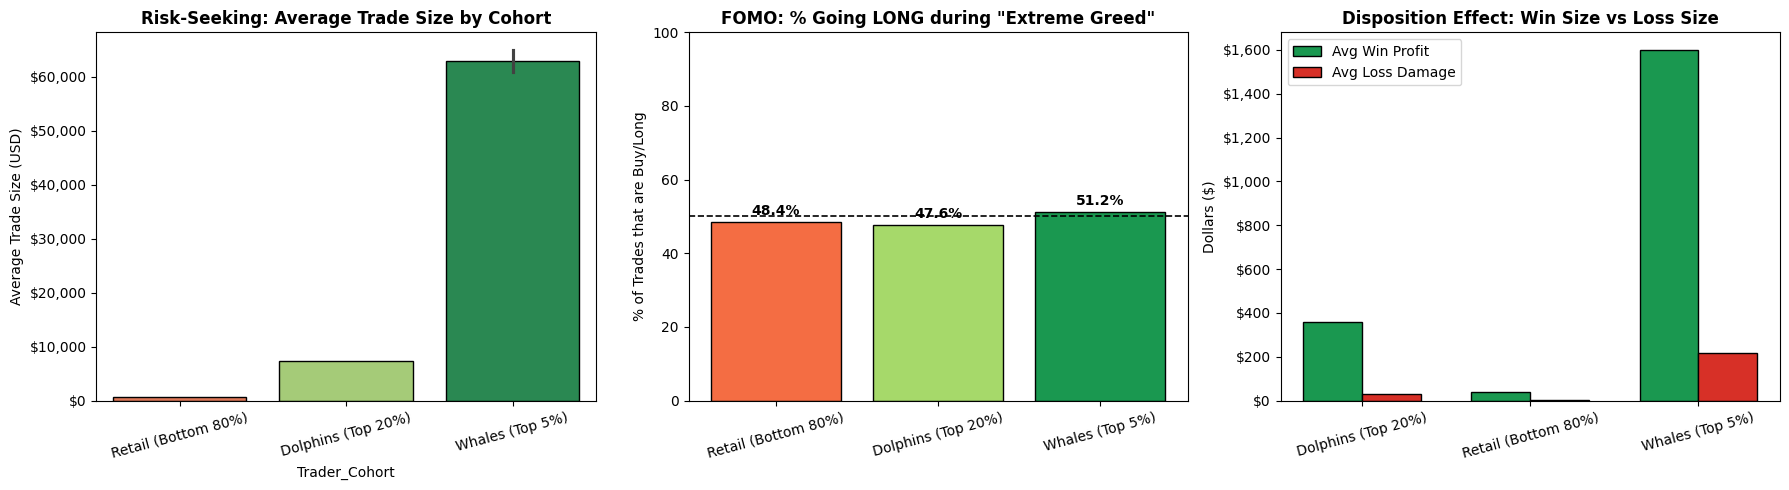

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

print("\n" + "="*60)
print("🧠 BEHAVIORAL FINANCE: PROVING PSYCHOLOGY WITH DATA")
print("="*60)

# ==========================================
# 1. WHALE VS RETAIL SEGMENTATION
# ==========================================
# We define "Whales" as the top 5% of trade sizes, "Dolphins" as the next 15%, and "Retail" as the bottom 80%
size_threshold_95 = merged_df['size_usd'].quantile(0.95)
size_threshold_80 = merged_df['size_usd'].quantile(0.80)

def segment_traders(size):
    if size >= size_threshold_95:
        return 'Whales (Top 5%)'
    elif size >= size_threshold_80:
        return 'Dolphins (Top 20%)'
    else:
        return 'Retail (Bottom 80%)'

merged_df['Trader_Cohort'] = merged_df['size_usd'].apply(segment_traders)

print(f"\n🐋 Segmentation Thresholds:")
print(f"Retail trades are under: ${size_threshold_80:,.2f} in size")
print(f"Whale trades are over:   ${size_threshold_95:,.2f} in size")

# ==========================================
# 2. THE FOMO METRIC (Momentum Chasing)
# ==========================================
# Do Retail traders go Long during Extreme Greed while Whales go Short?
fomo_df = merged_df[merged_df['classification'] == 'Extreme Greed']
fomo_stats = fomo_df.groupby('Trader_Cohort', observed=True).agg(
    Total_Greed_Trades=('is_win', 'count'),
    Percent_Going_Long=('is_long', lambda x: (x.mean() * 100).round(1))
    # Removed 'Average_Leverage' as 'leverage' column does not exist
).reindex(['Retail (Bottom 80%)', 'Dolphins (Top 20%)', 'Whales (Top 5%)'])

print("\n📈 FOMO BEHAVIOR DURING 'EXTREME GREED':")
print(fomo_stats.to_string())

# ==========================================
# 3. DISPOSITION EFFECT (Holding Losers)
# ==========================================
# Are traders cutting winners short and holding losers to zero?
disp_stats = merged_df.groupby('Trader_Cohort', observed=True).apply(
    lambda x: pd.Series({
        'Avg_Win_Size ($)': x[x['is_win']]['closed_pnl'].mean(),
        'Avg_Loss_Size ($)': x[~x['is_win']]['closed_pnl'].abs().mean()
    })
)
disp_stats['Loss_to_Win_Ratio'] = disp_stats['Avg_Loss_Size ($)'] / disp_stats['Avg_Win_Size ($)']

print("\n📉 DISPOSITION EFFECT (Are Losses larger than Wins?):")
print(disp_stats.round(2).to_string())

# ==========================================
# 4. VISUALIZING PSYCHOLOGY
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cohort_colors = {'Retail (Bottom 80%)': '#f46d43', 'Dolphins (Top 20%)': '#a6d96a', 'Whales (Top 5%)': '#1a9850'}

# ── A. Risk Seeking (Average Trade Size by Cohort) ──
sns.barplot(data=merged_df, x='Trader_Cohort', y='size_usd', ax=axes[0], palette=cohort_colors, edgecolor='black', order=['Retail (Bottom 80%)', 'Dolphins (Top 20%)', 'Whales (Top 5%)'], estimator=np.mean)
axes[0].set_title('Risk-Seeking: Average Trade Size by Cohort', fontweight='bold')
axes[0].set_ylabel('Average Trade Size (USD)')
axes[0].tick_params(axis="x", rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f"${val:,.0f}"))

# ── B. The FOMO Metric (Long bias in Extreme Greed) ──
bars = axes[1].bar(fomo_stats.index, fomo_stats['Percent_Going_Long'], color=[cohort_colors[x] for x in fomo_stats.index], edgecolor='black')
axes[1].axhline(50, color="black", lw=1.2, ls="--", label="50% (Neutral Bias)")
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 2, f"{b.get_height()}%", ha="center", fontweight='bold')
axes[1].set_title('FOMO: % Going LONG during "Extreme Greed"', fontweight='bold')
axes[1].set_ylabel('% of Trades that are Buy/Long')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=15)


# ── C. The Disposition Effect (Win/Loss Size) ──
x = np.arange(len(disp_stats))
w = 0.35
axes[2].bar(x - w/2, disp_stats['Avg_Win_Size ($)'], w, color='#1a9850', edgecolor='black', label='Avg Win Profit')
axes[2].bar(x + w/2, disp_stats['Avg_Loss_Size ($)'], w, color='#d73027', edgecolor='black', label='Avg Loss Damage')
axes[2].set_xticks(x)
axes[2].set_xticklabels(disp_stats.index, rotation=15)
axes[2].set_title('Disposition Effect: Win Size vs Loss Size', fontweight='bold')
axes[2].set_ylabel('Dollars ($)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f"${val:,.0f}"))
axes[2].legend()

plt.tight_layout()
plt.show()